In [9]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import matplotlib.pyplot as plt
LOG.propagate = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
LOG.debug("debug")
LOG.info("info")
LOG.warning("warning")
LOG.error("error")
LOG.critical("critical")

2025-03-05 14:56:35,906 | INFO     |: info
2025-03-05 14:56:35,908 | WARNING  |: warning
2025-03-05 14:56:35,909 | ERROR    |: error
2025-03-05 14:56:35,912 | CRITICAL |: critical


In [11]:
# Get ArtemisBLEController object
ble = get_ble_controller()
# Connect to the Artemis Device
ble.connect()

2025-03-05 14:56:37,018 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:e0:ec:f0:72:02


Exception: Could not find device with address: c0:e0:ec:f0:72:02 and service uuid: ae3527ce-10d8-45c0-9f82-2158e073efba

In [4]:
time_stamps = []
dist_short_list = []
time_short_list = []
dist_long_list  = []
time_long_list  = []
notification_count = 0
def tof_notification_handler(sender: int, data: bytearray):
    global notification_count
    try:
        message = data.decode("utf-8")  
        # Split by commas => [ 'SHORT:12.3', ' TIME_S:14', ' LONG:89.1', ' TIME_L:17' ]
        parts = message.split(',')
        # Parse each part
        short_str = parts[0].split(':')[1].strip()  # "12.3"
        time_s_str = parts[1].split(':')[1].strip() # "14"
        long_str  = parts[2].split(':')[1].strip()  # "89.1"
        time_l_str = parts[3].split(':')[1].strip() # "17"
        # Convert to float or int
        dist_short = float(short_str)
        t_short    = float(time_s_str)
        dist_long  = float(long_str)
        t_long     = float(time_l_str)
        # Append to our lists
        time_stamps.append(time.time())  # Or use your own timing approach
        dist_short_list.append(dist_short)
        time_short_list.append(t_short)
        dist_long_list.append(dist_long)
        time_long_list.append(t_long)
        notification_count += 1
        print(f"Notification #{notification_count}: {message}")
    except Exception as e:
        print(f"Error parsing notification: {e}")

In [5]:
ble.start_notify(ble.uuid['RX_STRING'], tof_notification_handler)
NUM_SAMPLES = 30
for i in range(NUM_SAMPLES):
    # Send command (TOF_DATA) with no extra arguments
    ble.send_command(CMD.TOF_DATA, "")
    time.sleep(5)  # Give it time to respond

KeyboardInterrupt: 

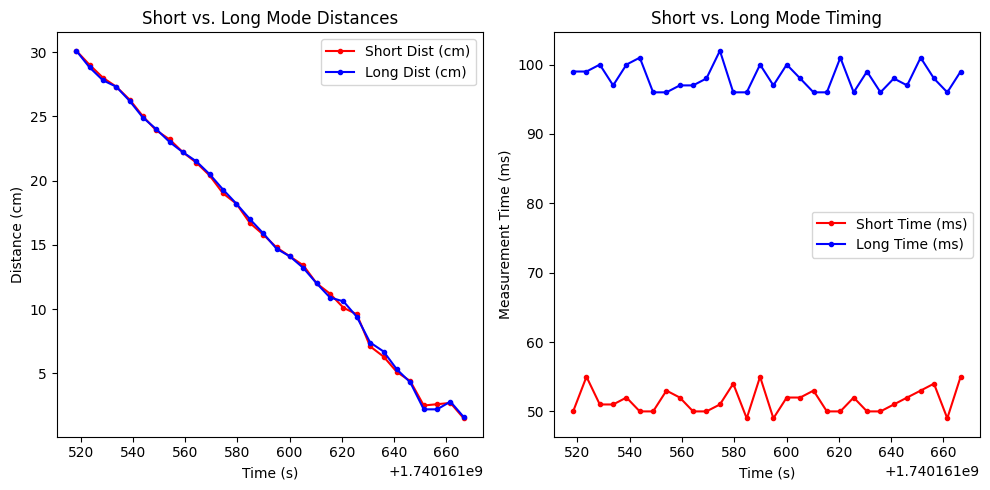

In [16]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(time_stamps, dist_short_list, 'r.-', label="Short Dist (cm)")
plt.plot(time_stamps, dist_long_list,  'b.-', label="Long Dist (cm)")
plt.xlabel("Time (s)")
plt.ylabel("Distance (cm)")
plt.legend()
plt.title("Short vs. Long Mode Distances")
plt.subplot(1,2,2)
plt.plot(time_stamps, time_short_list, 'r.-', label="Short Time (ms)")
plt.plot(time_stamps, time_long_list,  'b.-', label="Long Time (ms)")
plt.xlabel("Time (s)")
plt.ylabel("Measurement Time (ms)")
plt.legend()
plt.title("Short vs. Long Mode Timing")
plt.tight_layout()
plt.show()

In [4]:
# Global lists for ToF sensor data
tof_times = []
tof1_list = []
tof2_list = []

# Global lists for IMU data (complementary filtered pitch and roll)
imu_times = []
imu_pitch = []
imu_roll = []

notification_count = 0

def notification_handler(sender, data):
    global notification_count
    message = data.decode("utf-8").strip()
    notification_count += 1
    print(f"Notification #{notification_count}: {message}")
    
    # Check if message is ToF data: "TT:<time>|T1:<dist1>|T2:<dist2>"
    if message.startswith("TT:"):
        try:
            parts = message.split("|")
            t_val   = float(parts[0].split(":")[1])
            d1_val  = float(parts[1].split(":")[1])
            d2_val  = float(parts[2].split(":")[1])
            tof_times.append(t_val)
            tof1_list.append(d1_val)
            tof2_list.append(d2_val)
        except Exception as e:
            print("Error parsing ToF data:", message, e)
    
    # Check if message is IMU data (complementary filtered pitch & roll):
    # Format: "T:<time>|P:<pitch>|R:<roll>"
    elif message.startswith("T:") and "P:" in message and "R:" in message:
        try:
            parts = message.split("|")
            t_val     = float(parts[0].split(":")[1])
            pitch_val = float(parts[1].split(":")[1])
            roll_val  = float(parts[2].split(":")[1])
            imu_times.append(t_val)
            imu_pitch.append(pitch_val)
            imu_roll.append(roll_val)
        except Exception as e:
            print("Error parsing IMU pitch/roll data:", message, e)
    else:
        print(f"Unknown message format: {message}")

In [5]:
# Start notifications
ble.start_notify(ble.uuid["RX_STRING"], notification_handler)

In [6]:
# Clear old data
tof_times.clear()
tof1_list.clear()
tof2_list.clear()
imu_times.clear()
imu_pitch.clear()
imu_roll.clear()
notification_count = 0
print("Requesting 5s data capture...")

time.sleep(2)
# Send command to start recording (5 seconds) on the Artemis
ble.send_command(CMD.STORE_DUAL_TOF_IMU_DATA, "")

Requesting 5s data capture...


In [8]:
print("Now requesting data from board...")
ble.send_command(CMD.SEND_DUAL_TOF_IMU_DATA, "")
time.sleep(5)

Now requesting data from board...
Notification #1: TT:22569|T1:7|T2:17
Notification #2: TT:22631|T1:3|T2:18
Notification #3: TT:22730|T1:3|T2:17
Notification #4: TT:22825|T1:9|T2:17
Notification #5: TT:22926|T1:4|T2:16
Notification #6: TT:23028|T1:6|T2:17
Notification #7: TT:0|T1:0|T2:16
Notification #8: TT:23132|T1:7|T2:17
Notification #9: TT:23230|T1:7|T2:16
Notification #10: TT:23330|T1:1|T2:22
Notification #11: TT:23429|T1:9|T2:19
Notification #12: TT:23530|T1:4|T2:19
Notification #13: TT:23629|T1:4|T2:18
Notification #14: TT:23726|T1:2|T2:20
Notification #15: TT:23827|T1:3|T2:16
Notification #16: TT:23930|T1:2|T2:16
Notification #17: TT:24032|T1:3|T2:19
Notification #18: TT:24130|T1:3|T2:17
Notification #19: TT:24228|T1:5|T2:20
Notification #20: TT:24327|T1:5|T2:19
Notification #21: TT:24430|T1:5|T2:18
Notification #22: TT:24530|T1:6|T2:18
Notification #23: TT:24624|T1:4|T2:18
Notification #24: TT:24727|T1:6|T2:19
Notification #25: TT:24829|T1:5|T2:16
Notification #26: TT:24924|T1

In [9]:
print(f"Done receiving. Received {notification_count} notifications total.")

Done receiving. Received 956 notifications total.


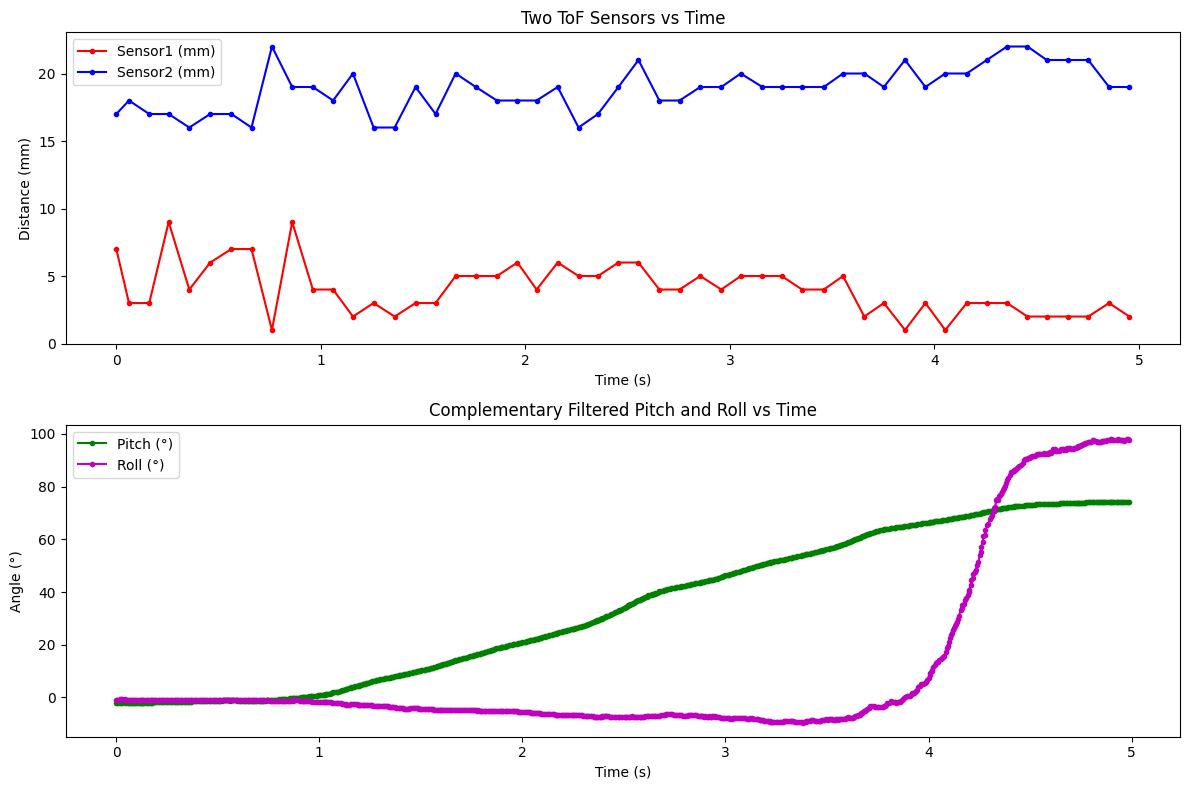

2025-02-25 20:01:50,922 | INFO     |: Disconnected from C0:E0:EC:F0:72:02


In [10]:
# ----- Process and Filter the ToF Data -----
# Filter indices where the computed time difference is non-negative
if len(tof_times) > 0:
    filtered_indices = [i for i, t in enumerate(tof_times) if (t - tof_times[0]) >= 0]
    filtered_tof_times = [(tof_times[i] - tof_times[0]) / 1000.0 for i in filtered_indices]
    filtered_tof1 = [tof1_list[i] for i in filtered_indices]
    filtered_tof2 = [tof2_list[i] for i in filtered_indices]
else:
    filtered_tof_times, filtered_tof1, filtered_tof2 = [], [], []

# Convert IMU times (ms) to seconds
if len(imu_times) > 0:
    imu_times_s = [(t - imu_times[0]) / 1000.0 for t in imu_times]
else:
    imu_times_s = []

# ----- Plot the Results -----
plt.figure(figsize=(12, 8))

# Plot ToF data in the top subplot
plt.subplot(2, 1, 1)
if len(filtered_tof_times) > 0:
    plt.plot(filtered_tof_times, filtered_tof1, 'r.-', label='Sensor1 (mm)')
    plt.plot(filtered_tof_times, filtered_tof2, 'b.-', label='Sensor2 (mm)')
    plt.xlabel("Time (s)")
    plt.ylabel("Distance (mm)")
    plt.title("Two ToF Sensors vs Time")
    plt.legend()
else:
    plt.title("No ToF data received")

# Plot IMU complementary filtered pitch & roll in the bottom subplot
plt.subplot(2, 1, 2)
if len(imu_times_s) > 0:
    plt.plot(imu_times_s, imu_pitch, 'g.-', label='Pitch (°)')
    plt.plot(imu_times_s, imu_roll, 'm.-', label='Roll (°)')
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (°)")
    plt.title("Complementary Filtered Pitch and Roll vs Time")
    plt.legend()
else:
    plt.title("No IMU pitch/roll data received")

plt.tight_layout()
plt.show()